In [17]:
from langgraph.graph import StateGraph , START , END
from typing import TypedDict


In [18]:
from typing import TypedDict

class variable(TypedDict):
    a: int
    b: int
    addresult: int
    multiplyresult: int

In [19]:
def funcadd(state: variable):
    return {
        "addresult": state["a"] + state["b"] 
    }

def funcmulti(state: variable):
    return {
        "multiplyresult": state["a"] * state["b"]
    }

In [20]:
graph = StateGraph(variable)

In [21]:
graph.add_node("add", funcadd)
graph.add_node("multiply", funcmulti)

graph.add_edge(START, "add")
graph.add_edge("add", "multiply")
graph.add_edge("multiply", END)

In [22]:
workflow = graph.compile()

In [23]:
result = workflow.invoke({
    "a": 10,
    "b": 20
})

print(result)

{'a': 10, 'b': 20, 'addresult': 30, 'multiplyresult': 200}


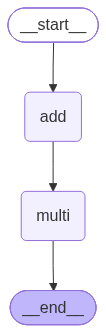

In [16]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())